In [1]:
import pandas as pd
import numpy as np
import openpyxl as px
import tkinter as tk
import PyInstaller

In [2]:
file = r"C:\Users\234500\Desktop\CDA.xlsx"
df = pd.read_excel(file)
df

,ITEM NO.,CABLE NO,SERVICE,CABLE,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,FROM,Unnamed: 9,ROUTE,TO,Unnamed: 12,REV.,REMARKS
0,NaN,NaN,NaN,TYPE,RATE(V),CORENO.,SIZE(mm2),LEN.(M),EQUIPMENT\nTAG NO.,EQUIPMENT\nLOCATION,NaN,EQUIPMENT\nTAG NO.,EQUIPMENT\nLOCATION,NaN,NaN
1,1.0,HECP-01-P-R1,EC TANK MAIN POWER,FPVC,600V,1/C,250,30,10NA 9/A 4M,ELECTRICAL ROOM 1F,CABLE TRAY LAYOUT SEE DWG. NO. : Y65-3-68-2023...,HECP-01,ELECTRICAL ROOM 1F,0.0,NaN
2,2.0,HECP-01-P-S1,EC TANK MAIN POWER,FPVC,600V,1/C,250,30,10NA 9/A 4M,ELECTRICAL ROOM 1F,CABLE TRAY LAYOUT SEE DWG. NO. : Y65-3-68-2023...,HECP-01,ELECTRICAL ROOM 1F,0.0,NaN
3,3.0,HECP-01-P-T1,EC TANK MAIN POWER,FPVC,600V,1/C,250,30,10NA 9/A 4M,ELECTRICAL ROOM 1F,CABLE TRAY LAYOUT SEE DWG. NO. : Y65-3-68-2023...,HECP-01,ELECTRICAL ROOM 1F,0.0,NaN
4,4.0,HECP-01-P-R2,EC TANK MAIN POWER,FPVC,600V,1/C,250,30,10NA 9/A 4M,ELECTRICAL ROOM 1F,CABLE TRAY LAYOUT SEE DWG. NO. : Y65-3-68-2023...,HECP-01,ELECTRICAL ROOM 1F,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,133.0,NaN,LINE SPEED (0-180mpm/0-10V),IPVV,600V,3/P,1.25,145,ID05,ELECTRICAL ROOM 3F,CABLE TRAY LAYOUT SEE DWG. NO. : Y65-3-68-2023...,BRUSH CONTROL PANEL\n(HBCP-01),RECTIFIER ROOM,0.0,INTERFACE
134,134.0,NaN,LINE SPEED (0-180mpm/0-10V),IPVV,600V,3/P,1.25,145,ID05,ELECTRICAL ROOM 3F,CABLE TRAY LAYOUT SEE DWG. NO. : Y65-3-68-2023...,BRUSH CONTROL PANEL\n(HBCP-01),RECTIFIER ROOM,0.0,INTERFACE
135,135.0,NaN,EC TANK INTERFACE-1,PVC,600V,12/C,1.25,145,IFC01,ELECTRICAL ROOM 3F,CABLE TRAY LAYOUT SEE DWG. NO. : Y65-3-68-2023...,BRUSH CONTROL PANEL\n(HBCP-01),RECTIFIER ROOM,0.0,INTERFACE
136,136.0,NaN,ALKALI BRUSH SECTION EMERGENCY STOP,PVC,600V,16/C,1.25,145,IFC01,ELECTRICAL ROOM 3F,CABLE TRAY LAYOUT SEE DWG. NO. : Y65-3-68-2023...,BRUSH CONTROL PANEL\n(HBCP-01),RECTIFIER ROOM,0.0,INTERFACE


In [4]:
window = tk.Tk()
window.title("CDA")
window.geometry("900x500")
window.resizable(False, False)
text1 = tk.Label(window, text="請輸入分類名稱", font=("微軟正黑體", 12),fg="blue",bg = "yellow")
text1.place(x=10, y=40)

text2 = tk.Label(text = "電纜規格",font = ("微軟正黑體",12),fg = "blue")
text2.place(x=175,y=10)

text3 = tk.Label(text = "電壓等級",font = ("微軟正黑體",12),fg = "blue")
text3.place(x=295,y=10)

text4 = tk.Label(text = "芯數",font = ("微軟正黑體",12),fg = "blue")
text4.place(x=430,y=10)

text5 = tk.Label(text = "線徑",font = ("微軟正黑體",12),fg = "blue")
text5.place(x=550,y=10)

text6 = tk.Label(text = "長度",font = ("微軟正黑體",12),fg = "blue")
text6.place(x=670,y=10)

enter1 = tk.Entry(window, width=10,font=("微軟正黑體", 12))
enter1.place(x=160, y=40)
enter1.insert(0,"TYPE")

enter2 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter2.place(x=280, y=40)
enter2.insert(0,"RATE(V)")

enter3 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter3.place(x=400, y=40)
enter3.insert(0,"CORENO.")

enter4 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter4.place(x=520, y=40)
enter4.insert(0,"SIZE(mm2)")

enter5 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter5.place(x=640, y=40)
enter5.insert(0,"LEN.(M)")

from tkinter import filedialog
from tkinter import ttk

tree = ttk.Treeview(window, show="headings")
tree.place(x=10, y=80, width=880, height=400)
def openfile():
        file = filedialog.askopenfilename(filetypes=[("Excel files", "*.xlsx")])
        df = pd.read_excel(file,header=1)
        s1 = enter1.get()
        s2 = enter2.get()
        s3 = enter3.get()
        s4 = enter4.get()
        s5 = enter5.get()
        S = df.iloc[0:1,:].columns.tolist()
        D = [s1,s2,s3,s4,s5] 
        if  s1 in S:
            tree['columns'] = D
        else:
            tree['columns'] = S
        for col in tree["columns"]:
            tree.heading(col,text=col)
            tree.column(col,width=120,anchor="center")
            
        for _,row in df.iterrows():
            try:
                tree.insert("", "end", values=row[tree["columns"]].tolist())
            except:
                 tree.delete()
            continue
                    

buttom = tk.Button(window, text="打開excel", font=("微軟正黑體", 12),command=openfile)
buttom.place(x=760, y=35)
window.mainloop()

In [129]:
import tkinter as tk
import pandas as pd
window = tk.Tk()
window.title("CDA")
window.geometry("900x600")
window.resizable(False, False)
text1 = tk.Label(window, text="請輸入分類名稱", font=("微軟正黑體", 12),fg="blue",bg = "yellow")
text1.place(x=10, y=40)

text2 = tk.Label(text = "電纜規格",font = ("微軟正黑體",12),fg = "blue")
text2.place(x=175,y=10)

text3 = tk.Label(text = "電壓等級",font = ("微軟正黑體",12),fg = "blue")
text3.place(x=295,y=10)

text4 = tk.Label(text = "芯數",font = ("微軟正黑體",12),fg = "blue")
text4.place(x=430,y=10)

text5 = tk.Label(text = "線徑",font = ("微軟正黑體",12),fg = "blue")
text5.place(x=550,y=10)

text6 = tk.Label(text = "長度",font = ("微軟正黑體",12),fg = "blue")
text6.place(x=670,y=10)

enter1 = tk.Entry(window, width=10,font=("微軟正黑體", 12))
enter1.place(x=160, y=40)
enter1.insert(0,"TYPE")

enter2 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter2.place(x=280, y=40)
enter2.insert(0,"RATE(V)")

enter3 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter3.place(x=400, y=40)
enter3.insert(0,"CORENO.")

enter4 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter4.place(x=520, y=40)
enter4.insert(0,"SIZE(mm2)")

enter5 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter5.place(x=640, y=40)
enter5.insert(0,"LEN.(M)")

from tkinter import filedialog
from tkinter import ttk

tree = ttk.Treeview(window, show="headings")
tree.place(x=10, y=80, width=880, height=400)

def openfile():
        file = filedialog.askopenfilename(filetypes=[("Excel files", "*.xlsx")])
        df = pd.read_excel(file,header=1)
        s1 = enter1.get()
        s2 = enter2.get()
        s3 = enter3.get()
        s4 = enter4.get()
        s5 = enter5.get()
        D = []
        for i in df:
            if i in [s1,s2,s3,s4,s5]:
              D.append(i)
              tree['columns'] = D
            for col in D:
                tree.heading(col,text=col)
                tree.column(col,width=120,anchor="center")
        for _,row in df.iterrows():
            tree.insert("", "end", values=row[D].tolist())
            
            

buttom = tk.Button(window, text="打開excel", font=("微軟正黑體", 12),command=openfile)
buttom.place(x=760, y=35)
window.mainloop()

In [6]:
s_columns = df.iloc[:,3:8]
print(s_columns)

    CABLE  Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7
0     TYPE    RATE(V)    CORENO.  SIZE(mm2)    LEN.(M)
1     FPVC       600V        1/C        250         30
2     FPVC       600V        1/C        250         30
3     FPVC       600V        1/C        250         30
4     FPVC       600V        1/C        250         30
..     ...        ...        ...        ...        ...
133   IPVV       600V        3/P       1.25        145
134   IPVV       600V        3/P       1.25        145
135    PVC       600V       12/C       1.25        145
136    PVC       600V       16/C       1.25        145
137    PVC       600V       12/C       1.25        145

[138 rows x 5 columns]


In [8]:
import tkinter as tk
import pandas as pd
from tkinter import filedialog
from tkinter import ttk

def openfile():
    file_path = filedialog.askopenfilename(filetypes=[("Excel files", "*.xlsx")])
    df = pd.read_excel(file_path)
    tree = ttk.Treeview(window, show="headings")
    tree.place(relx=0.03,rely=0.2,relheight=0.7,relwidth=0.94,anchor="nw")
    tree["columns"] = list(df)
    try:
        for col in tree["columns"]:
            tree.heading(col,text=col)
            tree.column(col,width=120)
        for _,row in df.iterrows():
            tree.insert("", "end", values=row.tolist())
            
            TE = 0
    except KeyError:
        TE = 1
        return TE


def readxls():
    
    sheet = pd.read_excel(r"C:\Users\234500\Desktop\CDA123.xlsx", sheet_name="材料表")
    tree = ttk.Treeview(window, show="headings")
    tree.place(relx=0.03,rely=0.2,relheight=0.7,relwidth=0.94,anchor="nw")
    tree["columns"] = list(sheet)
    try:
        for col in tree["columns"]:
            tree.heading(col,text=col)
            tree.column(col,width=120)
        for _,row in sheet.iterrows():
            tree.insert("", "end", values=row.tolist())
            
            TE = 0
    except KeyError:
        TE = 1
        return TE
    
    
def savexls():
    
    df = pd.read_excel(r"C:\Users\234500\Desktop\CDA.xlsx", header=1)
    df.fillna("", inplace=True)
    data = df.iloc[:, 3:8] 
    data1 = data.groupby(["TYPE",'RATE(V)','CORENO.','SIZE(mm2)']).agg({"LEN.(M)":"sum"})#.reset_index()
    data1.rename(columns={"LEN.(M)":"總長度"},inplace=True)
    #data1.index = range(1,len(data1)+1) 
    write = pd.ExcelWriter(r"C:\Users\234500\Desktop\CDA123.xlsx")
    data1.to_excel(write,sheet_name="材料表", index=True)
    
    data2 = data.groupby(["TYPE",'RATE(V)','CORENO.','SIZE(mm2)','LEN.(M)']).agg({"LEN.(M)":"count"})#.reset_index()
    data2.rename(columns={"LEN.(M)":"數量"},inplace=True)
    data2.to_excel(write,sheet_name="電纜長度", index=True)
    write.close()
    return data1,data2
    
    
window = tk.Tk()
window.title("CDA")
window.geometry("900x600")
window.resizable(False, False)
text1 = tk.Label(window, text="請輸入分類名稱", font=("微軟正黑體", 12),fg="blue",bg = "yellow")
text1.place(x=10, y=40)

text2 = tk.Label(text = "電纜規格",font = ("微軟正黑體",12),fg = "blue")
text2.place(x=175,y=10)

text3 = tk.Label(text = "電壓等級",font = ("微軟正黑體",12),fg = "blue")
text3.place(x=295,y=10)

text4 = tk.Label(text = "芯數",font = ("微軟正黑體",12),fg = "blue")
text4.place(x=430,y=10)

text5 = tk.Label(text = "線徑",font = ("微軟正黑體",12),fg = "blue")
text5.place(x=550,y=10)

text6 = tk.Label(text = "長度",font = ("微軟正黑體",12),fg = "blue")
text6.place(x=670,y=10)

enter1 = tk.Entry(window, width=10,font=("微軟正黑體", 12))
enter1.place(x=160, y=40)
enter1.insert(0,"TYPE")

enter2 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter2.place(x=280, y=40)
enter2.insert(0,"RATE(V)")

enter3 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter3.place(x=400, y=40)
enter3.insert(0,"CORENO.")

enter4 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter4.place(x=520, y=40)
enter4.insert(0,"SIZE(mm2)")

enter5 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter5.place(x=640, y=40)
enter5.insert(0,"LEN.(M)")

btn1 = tk.Button(window, text="打開excel", font=("微軟正黑體", 12),command=openfile)
btn1.place(x=760, y=35)

btn2 = tk.Button(window, text="儲存excel", font=("微軟正黑體", 12),command=savexls)
btn2.place(x=760, y=72)

btn3 = tk.Button(window, text="讀取材料表", font=("微軟正黑體", 12),command=readxls)                                                                    
btn3.place(x=520, y=72)

btn4 = tk.Button(window, text="讀取電纜長度", font=("微軟正黑體", 12),command=readxls)
btn4.place(x=640, y=72)









window.mainloop()




C:\Users\234500\AppData\Local\Temp\11\ipykernel_28892\2979288837.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("", inplace=True)


In [4]:
import pandas as pd
df = pd.read_excel(r"C:\Users\234500\Desktop\CDA.xlsx", header=1)
df.fillna(0, inplace=True)
data = df.iloc[:, 3:8] 
data1 = data.groupby(["TYPE",'RATE(V)','CORENO.','SIZE(mm2)']).agg({"LEN.(M)":"sum"})#.reset_index()
data1.rename(columns={"LEN.(M)":"總長度"},inplace=True)
#data1.fillna("--", inplace=True)
#data1.index = range(1,len(data1)+1) 
write = pd.ExcelWriter(r"C:\Users\234500\Desktop\CDA123.xlsx")
data1.to_excel(write,sheet_name="材料表", index=True)

data2 = data.groupby(["TYPE",'RATE(V)','CORENO.','SIZE(mm2)','LEN.(M)']).agg({"LEN.(M)":"count"})#.reset_index()
data2.rename(columns={"LEN.(M)":"數量"},inplace=True)
#data2.fillna("--", inplace=True)
data2.to_excel(write,sheet_name="電纜長度", index=True)
write.close()

In [ ]:
import tkinter as tk
import pandas as pd
from tkinter import filedialog
from tkinter import ttk
from matplotlib import pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import openpyxl as px


def draw_1():
    df = pd.read_excel(file_path,header=1)
    df1 = df.groupby(by = "TYPE")["LEN.(M)"].sum()
    plt.figure(figsize=(8,8))
    df1.plot.bar()
    for i in range(len(df1)):
        plt.text(i,df1[i],df1[i],ha='center',va='bottom')
    plt.xticks(rotation=45)

    sec1_window = tk.Tk()
    sec1_window.title("電纜長度表")
    sec1_window.geometry("600x550")
    
    canvas = FigureCanvasTkAgg(plt.gcf(), master=sec1_window)
    canvas.draw()
    canvas.get_tk_widget().pack(side=tk.TOP, fill=tk.BOTH, expand=True)
    plt.close()
    sec1_window.mainloop()
    


def draw_2():
    df = pd.read_excel(file_path,header=1)
    df2 = df.groupby(['TYPE'])['LEN.(M)'].count()
    plt.figure(figsize=(8,8))
    df2.plot.bar()
    for i in range(len(df2)):
        plt.text(i,df2[i],df2[i],ha='center',va='bottom')
    plt.xticks(rotation=45)

    sec2_window = tk.Tk()
    sec2_window.title("數量圖")
    sec2_window.geometry("600x550")
    canvas = FigureCanvasTkAgg(plt.gcf(), master=sec2_window)
    canvas.draw()
    canvas.get_tk_widget().pack(side=tk.TOP, fill=tk.BOTH, expand=True)
    plt.close()
    sec2_window.mainloop()
    


def readxls(file_path,sheet_name):
    sheet = pd.read_excel(file_path, sheet_name=sheet_name)
    sheet.fillna("--", inplace=True)
    tree = ttk.Treeview(window, show="headings")
    tree.place(relx=0.03,rely=0.2,relheight=0.7,relwidth=0.94,anchor="nw")
    ncol = len(sheet.columns)
    title = [""]
    for i in range(ncol):
         title.append(i+1)
    tree['column'] = title
       
    for col in title:
            tree.heading(col,text=col,anchor="center")
            tree.column(col,width=120,anchor="center")
    tree.insert("", "end", values= [1]+sheet.columns.tolist())
    for index,row in sheet.iterrows():
        tree.insert("", "end", values= [index+2]+row.tolist())



def transxls_1():
    global file_path,save_file,btn5,btn6
    data = pd.read_excel(file_path,header=1)
    s1 = enter1.get()
    s2 = enter2.get()
    s3 = enter3.get()
    s4 = enter4.get()
    s5 = enter5.get()
    S = [s1,s2,s3,s4]
    D = []
    for i in data:
        if i in S:
            D.append(i)
    data.fillna("", inplace=True)
    data.groupby(D,sort=True)
    data1 = data.groupby(D).agg({"LEN.(M)":"sum"})
    data1.rename(columns={"LEN.(M)":"總長度"},inplace=True)
    
    with pd.ExcelWriter(save_file, engine='openpyxl',mode='a',if_sheet_exists='overlay') as writer:
        data1.to_excel(writer, sheet_name="電纜長度表", index=True)
        if '空白' in writer.book.sheetnames:
            writer.book.remove(writer.book['空白'])

    readxls(save_file,"電纜長度表")

    btn5 = tk.Button(window, text="電纜長度圖", font=("微軟正黑體", 12),command=draw_1)
    btn5.place(x=20, y=550)
    btn6.place_forget()



def transxls_2():
    global file_path,save_file,btn5,btn6
    data = pd.read_excel(file_path,header=1)
    s1 = enter1.get()
    s2 = enter2.get()
    s3 = enter3.get()
    s4 = enter4.get()
    s5 = enter5.get()
    S = [s1,s2,s3,s4,s5]
    D = []
    for i in data:
        if i in S:
            D.append(i)
    data.fillna("", inplace=True)
    data.groupby(D,sort=True)
    data2 = data.groupby(D).agg({"LEN.(M)":"count"})#.reset_index()
    data2.rename(columns={"LEN.(M)":"數量"},inplace=True)
    
    with pd.ExcelWriter(save_file, engine='openpyxl',mode='a',if_sheet_exists='overlay') as writer:
        data2.to_excel(writer, sheet_name="數量表", index=True)
        if '空白' in writer.book.sheetnames:
            writer.book.remove(writer.book['空白'])

    readxls(save_file,"數量表")   

    btn6 = tk.Button(window, text="數量圖", font=("微軟正黑體", 12),command=draw_2)
    btn6.place(x=20, y=550)
    btn5.place_forget()

def empty_xls():
    wb = px.Workbook()
    wb.active.title = '空白'
    wb.save(save_file)


def save():
    global save_file
    save_file = filedialog.asksaveasfilename(filetypes=[("Excel files", "*.xlsx")])
    empty_xls()
    btn2 = tk.Button(window, text="電纜長度表", font=("微軟正黑體", 12),command=transxls_1)
    btn2.place(x=780, y=550)
    btn3 = tk.Button(window, text="數量表", font=("微軟正黑體", 12),command=transxls_2)                                                                    
    btn3.place(x=700, y=550)



def openfile():
    global file_path
    file_path = filedialog.askopenfilename(filetypes=[("Excel files", "*.xlsx")])
    df = pd.read_excel(file_path)
    tree = ttk.Treeview(window, show="headings")
    tree.place(relx=0.03,rely=0.2,relheight=0.7,relwidth=0.94,anchor="nw")
    tree["columns"] = list(df)
    
    for col in tree["columns"]:
        tree.heading(col,text=col)
        tree.column(col,width=120)
    for _,row in df.iterrows():
        tree.insert("", "end", values=row.tolist())

    btn4 = tk.Button(window, text="儲存", font=("微軟正黑體", 12),command=save)
    btn4.place(x=780, y=550)
    
                


window = tk.Tk()
window.title("CDA")
window.geometry("900x600")
window.resizable(False, False)
text1 = tk.Label(window, text="請輸入分類名稱", font=("微軟正黑體", 12),fg="blue",bg = "yellow")
text1.place(x=10, y=40)

text2 = tk.Label(text = "電纜規格",font = ("微軟正黑體",12),fg = "blue")
text2.place(x=175,y=10)

text3 = tk.Label(text = "電壓等級",font = ("微軟正黑體",12),fg = "blue")
text3.place(x=295,y=10)

text4 = tk.Label(text = "芯數",font = ("微軟正黑體",12),fg = "blue")
text4.place(x=430,y=10)

text5 = tk.Label(text = "線徑",font = ("微軟正黑體",12),fg = "blue")
text5.place(x=550,y=10)

text6 = tk.Label(text = "長度",font = ("微軟正黑體",12),fg = "blue")
text6.place(x=670,y=10)

enter1 = tk.Entry(window, width=10,font=("微軟正黑體", 12))
enter1.place(x=160, y=40)
enter1.insert(0,"TYPE")

enter2 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter2.place(x=280, y=40)
enter2.insert(0,"RATE(V)")

enter3 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter3.place(x=400, y=40)
enter3.insert(0,"CORENO.")

enter4 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter4.place(x=520, y=40)
enter4.insert(0,"SIZE(mm2)")

enter5 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter5.place(x=640, y=40)
enter5.insert(0,"LEN.(M)")

btn1 = tk.Button(window, text="打開excel", font=("微軟正黑體", 12),command=openfile)
btn1.place(x=760, y=35)

window.mainloop()

In [9]:
import tkinter as tk
import pandas as pd
from tkinter import filedialog
from tkinter import ttk

def openfile():
    global file_path
    file_path = filedialog.askopenfilename(filetypes=[("Excel files", "*.xlsx")])
    df = pd.read_excel(file_path)
    tree = ttk.Treeview(window, show="headings")
    tree.place(relx=0.03,rely=0.2,relheight=0.7,relwidth=0.94,anchor="nw")
    tree["columns"] = list(df)
    
    for col in tree["columns"]:
        tree.heading(col,text=col)
        tree.column(col,width=120)
    for _,row in df.iterrows():
        tree.insert("", "end", values=row.tolist())
    
    btn2 = tk.Button(window, text="電纜長度表", font=("微軟正黑體", 12),command=transxls_1)
    btn2.place(x=780, y=550)
    btn3 = tk.Button(window, text="數量表", font=("微軟正黑體", 12),command=transxls_2)                                                                    
    btn3.place(x=700, y=550)


def transxls_1():
    global file_path
    data = pd.read_excel(file_path,header=1)
    s1 = enter1.get()
    s2 = enter2.get()
    s3 = enter3.get()
    s4 = enter4.get()
    s5 = enter5.get()
    S = [s1,s2,s3,s4,s5]
    D = []
    for i in data:
        if i in S:
            D.append(i)
    data.fillna("", inplace=True)
    data.groupby(D,sort=True)
    data1 = data.groupby(D).agg({"LEN.(M)":"sum"})
    data1.rename(columns={"LEN.(M)":"總長度"},inplace=True)
    write = pd.ExcelWriter(r"C:\Users\234500\Desktop\CDA123.xlsx")
    data1.to_excel(write,sheet_name="電纜長度", index=True)
    write.close()
    readxls("電纜長度")
    
def transxls_2():
    global file_path
    global write
    data = pd.read_excel(file_path,header=1)
    s1 = enter1.get()
    s2 = enter2.get()
    s3 = enter3.get()
    s4 = enter4.get()
    s5 = enter5.get()
    S = [s1,s2,s3,s4,s5]
    D = []
    for i in data:
        if i in S:
            D.append(i)
    data.fillna("", inplace=True)
    data.groupby(D,sort=True)
    data2 = data.groupby(D).agg({"LEN.(M)":"count"})#.reset_index()
    data2.rename(columns={"LEN.(M)":"數量"},inplace=True)
    write = pd.ExcelWriter(r"C:\Users\234500\Desktop\CDA123.xlsx")
    data2.to_excel(write,sheet_name="電纜數量", index=True)
    write.close()
    readxls("電纜數量")   

def readxls(sheet_name):
    global write
    sheet = pd.read_excel(write, sheet_name=sheet_name)
    sheet.fillna("--", inplace=True)
    tree = ttk.Treeview(window, show="headings")
    tree.place(relx=0.03,rely=0.2,relheight=0.7,relwidth=0.94,anchor="nw")
    ncol = len(sheet.columns)
    title = [""]
    for i in range(ncol):
         title.append(i+1)
    tree['column'] = title
       
    for col in title:
            tree.heading(col,text=col,anchor="center")
            tree.column(col,width=120,anchor="center")
    tree.insert("", "end", values= [1]+sheet.columns.tolist())
    for index,row in sheet.iterrows():
        tree.insert("", "end", values= [index+2]+row.tolist())
                


window = tk.Tk()
window.title("CDA")
window.geometry("900x600")
window.resizable(False, False)
text1 = tk.Label(window, text="請輸入分類名稱", font=("微軟正黑體", 12),fg="blue",bg = "yellow")
text1.place(x=10, y=40)

text2 = tk.Label(text = "電纜規格",font = ("微軟正黑體",12),fg = "blue")
text2.place(x=175,y=10)

text3 = tk.Label(text = "電壓等級",font = ("微軟正黑體",12),fg = "blue")
text3.place(x=295,y=10)

text4 = tk.Label(text = "芯數",font = ("微軟正黑體",12),fg = "blue")
text4.place(x=430,y=10)

text5 = tk.Label(text = "線徑",font = ("微軟正黑體",12),fg = "blue")
text5.place(x=550,y=10)

text6 = tk.Label(text = "長度",font = ("微軟正黑體",12),fg = "blue")
text6.place(x=670,y=10)

enter1 = tk.Entry(window, width=10,font=("微軟正黑體", 12))
enter1.place(x=160, y=40)
enter1.insert(0,"TYPE")

enter2 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter2.place(x=280, y=40)
enter2.insert(0,"RATE(V)")

enter3 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter3.place(x=400, y=40)
enter3.insert(0,"CORENO.")

enter4 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter4.place(x=520, y=40)
enter4.insert(0,"SIZE(mm2)")

enter5 = tk.Entry(window,width=10, font=("微軟正黑體", 12))
enter5.place(x=640, y=40)
enter5.insert(0,"LEN.(M)")

btn1 = tk.Button(window, text="打開excel", font=("微軟正黑體", 12),command=openfile)
btn1.place(x=760, y=35)

window.mainloop()

C:\Users\234500\AppData\Local\Temp\3\ipykernel_5392\3931242608.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i,df1[i],df1[i],ha='center',va='bottom')


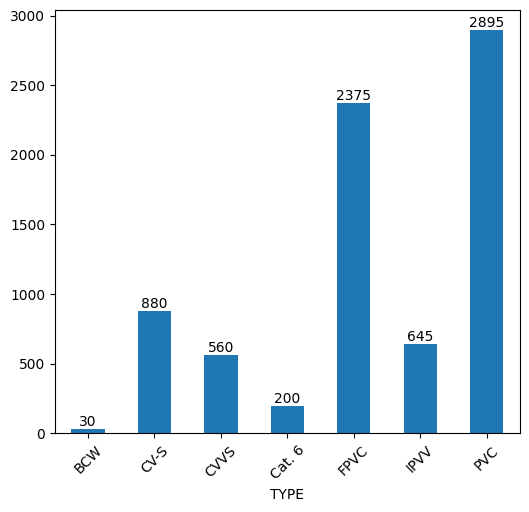

In [6]:
df = pd.read_excel(file_path,header=1)
df1 = df.groupby(by = "TYPE")["LEN.(M)"].sum()
df1.plot.bar()
for i in range(len(df1)):
    plt.text(i,df1[i],df1[i],ha='center',va='bottom')
plt.xticks(rotation=45)
sec1_window = tk.Tk()
sec1_window.title("電纜長度表")
sec1_window.geometry("600x550")
canvas = FigureCanvasTkAgg(plt.gcf(), master=sec1_window)
canvas.draw()
canvas.get_tk_widget().pack(side=tk.TOP, fill=tk.BOTH, expand=True)
sec1_window.mainloop()

C:\Users\234500\AppData\Local\Temp\3\ipykernel_5392\2128087562.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i,df2[i],df2[i],ha='center',va='bottom')


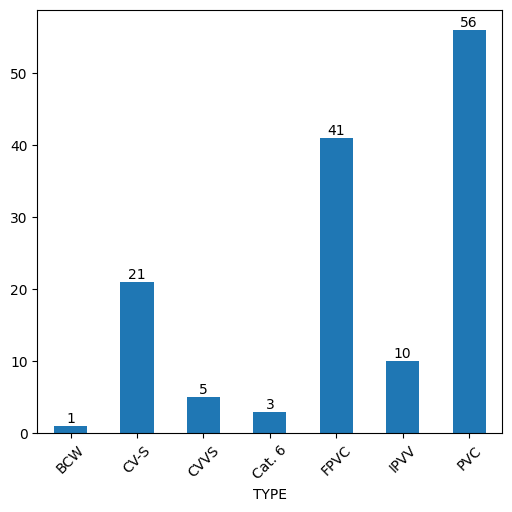

In [7]:

df = pd.read_excel(file_path,header=1)
df2 = df.groupby(['TYPE'])['LEN.(M)'].count()
df2.plot.bar()
for i in range(len(df2)):
    plt.text(i,df2[i],df2[i],ha='center',va='bottom')
plt.xticks(rotation=45)
sec2_window = tk.Tk()
sec2_window.title("數量圖")
sec2_window.geometry("600x550")
canvas = FigureCanvasTkAgg(plt.gcf(), master=sec2_window)
canvas.draw()
canvas.get_tk_widget().pack(side=tk.TOP, fill=tk.BOTH, expand=True)
sec2_window.mainloop()